# Prophet Model (Baseline Time-Series Model)


In [3]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

In [4]:
df = pd.read_csv("../data/processed/clean_price_data.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

In [5]:
prophet_df = df.rename(columns={
    "timestamp": "ds",
    "price": "y"
})

In [6]:
train = prophet_df[prophet_df["ds"] < "2026-01-01"].copy()
test = prophet_df[prophet_df["ds"] >= "2026-01-01"].copy()

In [7]:
model = Prophet()

model.fit(train)

09:36:04 - cmdstanpy - INFO - Chain [1] start processing
09:36:12 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(periods=len(test), freq="h")

forecast = model.predict(future)

In [9]:
forecast_test = forecast.set_index("ds").loc[test["ds"]]

y_pred = forecast_test["yhat"].values
y_true = test["y"].values

In [10]:
mae = mean_absolute_error(y_true, y_pred)

print(f"Prophet MAE: {mae:.3f}")

Prophet MAE: 27.006


In [13]:
prophet_results = test[["ds", "y"]].copy()
prophet_results["prophet_prediction"] = y_pred

prophet_results = prophet_results.rename(columns={
    "ds": "timestamp",
    "y": "price"
})

prophet_results.head()

,timestamp,price,prophet_prediction
26301,2026-01-01 00:00:00,58.28,80.896261
26302,2026-01-01 01:00:00,42.40,77.579033
26303,2026-01-01 02:00:00,19.57,72.680159
26304,2026-01-01 03:00:00,6.29,68.493786
26305,2026-01-01 04:00:00,3.09,70.168407


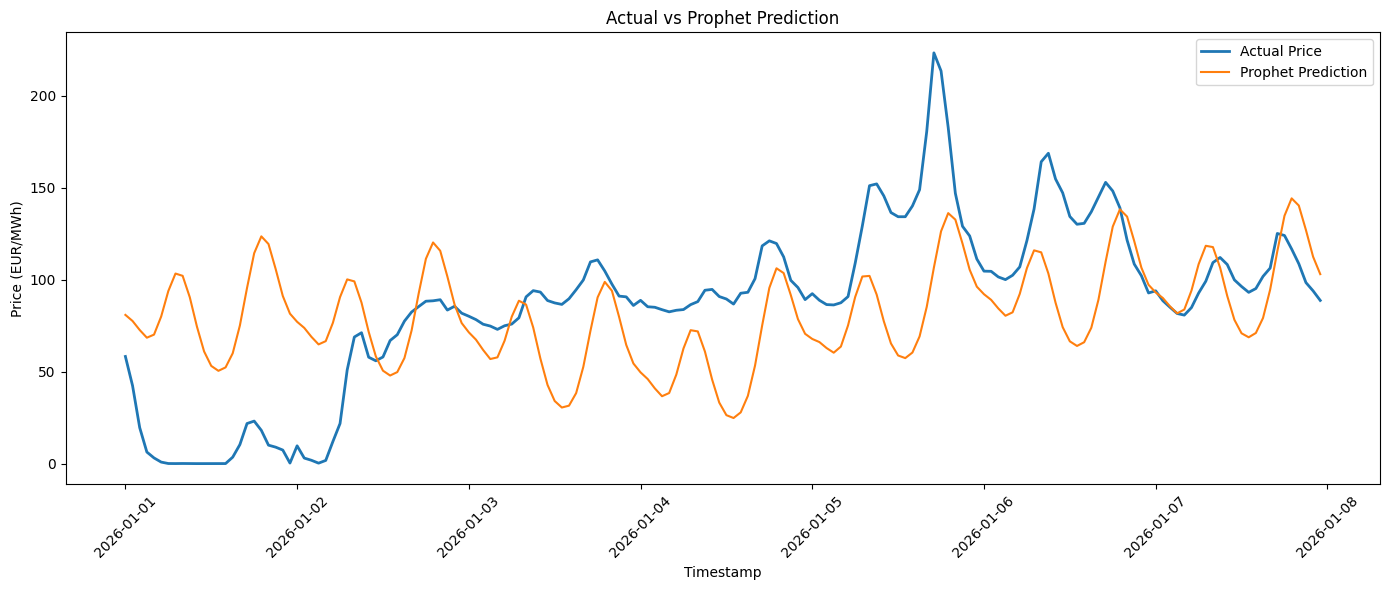

In [15]:
import matplotlib.pyplot as plt

plot_data = prophet_results[
    (prophet_results["timestamp"] >= "2026-01-01") &
    (prophet_results["timestamp"] < "2026-01-08")
].copy()

plt.figure(figsize=(14, 6))

plt.plot(plot_data["timestamp"], plot_data["price"], label="Actual Price", linewidth=2)
plt.plot(plot_data["timestamp"], plot_data["prophet_prediction"], label="Prophet Prediction")

plt.title("Actual vs Prophet Prediction")
plt.xlabel("Timestamp")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/figures/actual_vs_prophet_prediction.png", dpi=300)
plt.show()